## 1 - Carregamento e entendimento dos dados

In [61]:
import pandas as pd

df=pd.read_csv('/home/juliana-donato/Documentos/Projetos/churn-telecom/data/Telco-Customer-Churn.csv')

## 2 - Entendimento dos Dados

In [62]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3 - Limpeza de Dados

### 3.1 - PADRONIZAÇÃO DOS NOMES DAS COLUNAS
Usando snake_case e lower:

In [63]:
import re

def to_snake_case(col):
    return re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()

df.columns = [to_snake_case(c) for c in df.columns]

df = df.rename(columns={'streaming_t_v': 'streaming_tv'})


df.columns

Index(['customer_i_d', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

### 3.2 - CORREÇÃO DE TIPO<br>
Uma coluna que deveria ser do tipo float (total_charges) está como string. Então, primeiro é preciso eliminar strings vazias ou espaços das células. Para isso, faço a soma de quantas células possuem strings vazias ou espaços, para saber quantas elas são e traçar a estratégia de solução.

INVESTIGAÇÃO:

In [64]:
df['total_charges'].apply(lambda x: x.strip()).eq('').sum()

np.int64(11)

Por que justamente essas 11 linhas vieram em branco, e não outras?

CHECAGEM:

In [65]:
df[df['total_charges'].apply(lambda x: x.strip()) == '']['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

Conclui-se que os valores de 'total_charges' com strings vazias também possuem a coluna 'tenure' com valor=0. Ou seja, clientes que ainda não registraram 1 mês de contrato com a empresa, por isso não possuem valor total acumulado.

Portanto, a estratégia adequada para tratar as linhas com string vazia em 'total_charges' é substitui-las pelo número 0.

CORREÇÃO:

In [66]:
df['total_charges'] = df['total_charges'].replace(' ', '0')
df['total_charges'] = pd.to_numeric(df['total_charges'])

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_i_d       7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

Agora todas as linhas em 'total_charges' estão no formato float64 corretamente.

Agora, conferindo para saber se todos esses clientes com 'tenure' == 0 são clientes recém-chegados mesmo e não uma anomalia dos dados, logo, possuem a coluna 'churn' == 'No'.

In [68]:
df[df['tenure'] == 0]['churn'].value_counts()

churn
No    11
Name: count, dtype: int64

Isso mostra que todos são clientes recém-chegados.

### 3.3 - REMOÇÃO DE COLUNAS SEM PODER PREDITIVO<br>
Analisando a coluna 'customer_i_d', sua cardinalidade é igual ao número de linhas, ou seja, há um ID único para cada linha. Isso significa que não há padrão repetido para aprendizagem.

Portanto, é possível excluir essa coluna do dataframe.

In [69]:
df = df.drop(['customer_i_d'], axis=1)

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   str    
 1   senior_citizen     7043 non-null   int64  
 2   partner            7043 non-null   str    
 3   dependents         7043 non-null   str    
 4   tenure             7043 non-null   int64  
 5   phone_service      7043 non-null   str    
 6   multiple_lines     7043 non-null   str    
 7   internet_service   7043 non-null   str    
 8   online_security    7043 non-null   str    
 9   online_backup      7043 non-null   str    
 10  device_protection  7043 non-null   str    
 11  tech_support       7043 non-null   str    
 12  streaming_tv       7043 non-null   str    
 13  streaming_movies   7043 non-null   str    
 14  contract           7043 non-null   str    
 15  paperless_billing  7043 non-null   str    
 16  payment_method     7043 non-null   

PRÓXIMO PASSO: EDA das variáveis categóricas x Churn (etapa 4)
<br>Limpeza já feita: TotalCharges (float), customerID removido, Churn 73,5%/26,5%

### 3.4 - CONSISTÊNCIA CATEGÓRICA (colapso de valores redundantes)
Verificando os valores únicos das variáveis categóricas:

In [71]:
cols = [
    'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',
    'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'churn'
]

for col in cols:
    print(f"\nColuna: {col}")
    print(f"Valores únicos: {list(df[col].unique())}")


Coluna: gender
Valores únicos: ['Female', 'Male']

Coluna: senior_citizen
Valores únicos: [np.int64(0), np.int64(1)]

Coluna: partner
Valores únicos: ['Yes', 'No']

Coluna: dependents
Valores únicos: ['No', 'Yes']

Coluna: phone_service
Valores únicos: ['No', 'Yes']

Coluna: multiple_lines
Valores únicos: ['No phone service', 'No', 'Yes']

Coluna: internet_service
Valores únicos: ['DSL', 'Fiber optic', 'No']

Coluna: online_security
Valores únicos: ['No', 'Yes', 'No internet service']

Coluna: online_backup
Valores únicos: ['Yes', 'No', 'No internet service']

Coluna: device_protection
Valores únicos: ['No', 'Yes', 'No internet service']

Coluna: tech_support
Valores únicos: ['No', 'Yes', 'No internet service']

Coluna: streaming_tv
Valores únicos: ['No', 'Yes', 'No internet service']

Coluna: streaming_movies
Valores únicos: ['No', 'Yes', 'No internet service']

Coluna: contract
Valores únicos: ['Month-to-month', 'One year', 'Two year']

Coluna: paperless_billing
Valores únicos: ['Ye

Verificando se quando 'internet_service' == 'No', o valor das colunas ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'] são todos 'No internet service':

In [72]:
df[df['internet_service'] == 'No'][['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']].apply(lambda col: col.unique())

,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


Portanto, as 6 colunas ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'] são dependentes da coluna 'internet_service'. Ou seja, o cliente que não possui o serviço de internet também não possui nenhum dos serviços retratados por essas colunas. Logo, podemos substituir 'No internet service' nessas colunas dependentes por 'No'.

In [73]:
cols_dependentes = ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

for col in cols_dependentes:
    df[col] = df[col].replace('No internet service', 'No')

Verificando se quando 'phone_service' == 'No', o valor da coluna 'multiple_lines' é 'No phone service':

In [74]:
df[df['phone_service'] == 'No']['multiple_lines'].unique()

<StringArray>
['No phone service']
Length: 1, dtype: str

Logo, o cliente que não possui serviço telefônico também não possui multiplas linhas, sendo possível colapsar 'No phone service' em 'No' para evitar redundância com a informação que já está em 'phone_service'.

In [75]:
df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')

## 4 - Análise Exploratória dos Dados (EDA)

### 4.1 - BALANCEAMENTO DA VARIÁVEL-ALVO (churn)

Verificando a proporção de clientes que cancelaram vs que não cancelaram.

In [77]:
df['churn'].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### 4.2 - EXPLORAÇÃO DOS VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

In [76]:
cols = [
    'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',
    'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'churn'
]

for col in cols:
    print(f"\nColuna: {col}")
    print(f"Valores únicos: {list(df[col].unique())}")


Coluna: gender
Valores únicos: ['Female', 'Male']

Coluna: senior_citizen
Valores únicos: [np.int64(0), np.int64(1)]

Coluna: partner
Valores únicos: ['Yes', 'No']

Coluna: dependents
Valores únicos: ['No', 'Yes']

Coluna: phone_service
Valores únicos: ['No', 'Yes']

Coluna: multiple_lines
Valores únicos: ['No', 'Yes']

Coluna: internet_service
Valores únicos: ['DSL', 'Fiber optic', 'No']

Coluna: online_security
Valores únicos: ['No', 'Yes']

Coluna: online_backup
Valores únicos: ['Yes', 'No']

Coluna: device_protection
Valores únicos: ['No', 'Yes']

Coluna: tech_support
Valores únicos: ['No', 'Yes']

Coluna: streaming_tv
Valores únicos: ['No', 'Yes']

Coluna: streaming_movies
Valores únicos: ['No', 'Yes']

Coluna: contract
Valores únicos: ['Month-to-month', 'One year', 'Two year']

Coluna: paperless_billing
Valores únicos: ['Yes', 'No']

Coluna: payment_method
Valores únicos: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

Coluna: churn


### 4.3 - ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS NUMÉRICAS

Verificando as variáveis numéricas com .describe()

In [79]:
df[['tenure', 'monthly_charges', 'total_charges']].describe()

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 4.4 - ANÁLISE UNIVARIADA

Criando gráficos para interpretar visualmente os valores das colunas:

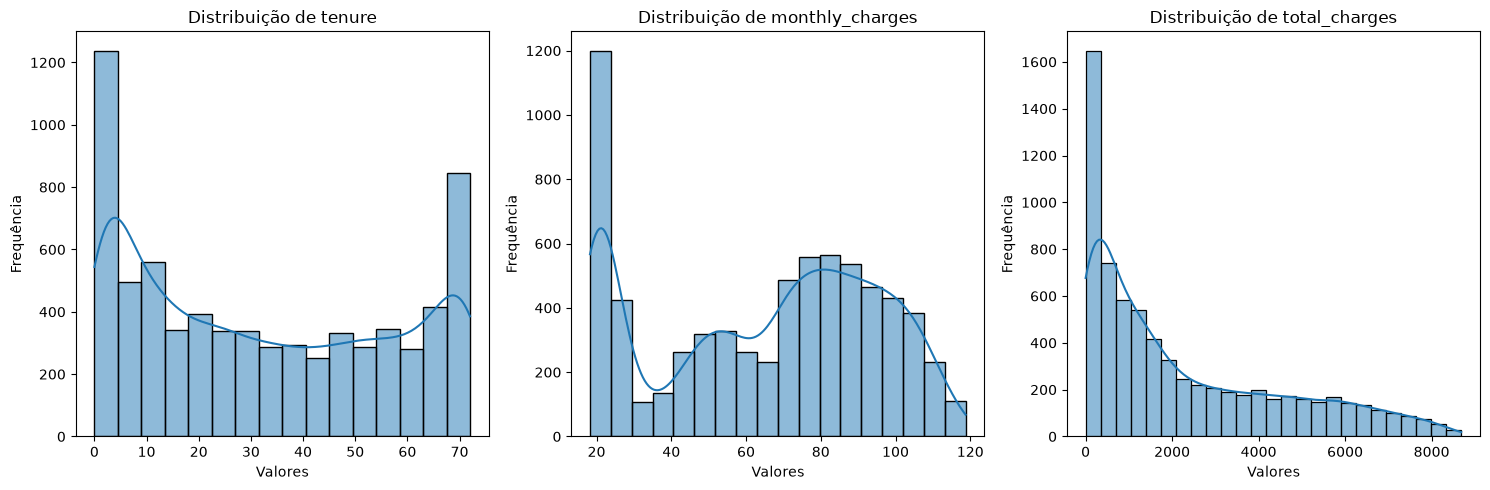

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['tenure', 'monthly_charges', 'total_charges']):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(f'Distribuição de {col}')
    ax.set_xlabel('Valores')
    ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

'tenure' bimodal, com pico em 0 e pico em ~70 <br>
'monthly_charges' com pico isolado perto de 20 e um platô maior ente 70-100 <br>
'total_charges' com cauda longa decrescente (consistente com a assimetria calculada antes)

Verificando a concentração de clientes em 'monthly_charges' nos valores próximos a 20. Suspeita: Clientes sem serviço de internet, somente telefonia.

In [86]:
df[df['internet_service'] == 'No']['monthly_charges'].describe()

count    1526.000000
mean       21.079194
std         2.164221
min        18.250000
25%        19.700000
50%        20.150000
75%        20.900000
max        26.900000
Name: monthly_charges, dtype: float64

Suspeita confirmada com evidência numérica: concentração de clientes em 'monthly_charges' próximo de 20 é formada por clientes que possuem somente plano telefônico, sem internet.

### 4.5 - ANÁLISE BIVARIADA (CATEGÓRICAS X CHURN)

Verificando a taxa de 'churn' de acordo com 'tenure' (meses de contrato):

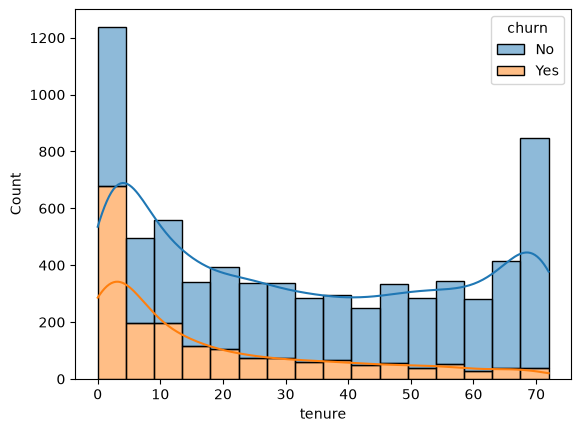

In [85]:
sns.histplot(data=df, x='tenure', hue='churn', multiple='stack', kde=True)
plt.show()

A fatia laranja (Yes, cancelou) é proporcionalmente maior nas primeiras barras ('tenure' baixo) e praticamente desaparece nas últimas. Mas é preciso confirmar as proporções.

Separando a taxa de cancelamento em períodos de 12 meses e verificando seu percentual:

In [89]:
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72], include_lowest=True)

df.groupby('tenure_bin', observed=True)['churn'].apply(lambda x: (x == 'Yes').mean()).reset_index(name='churn_rate')

,tenure_bin,churn_rate
0,"(-0.001, 12.0]",0.474382
1,"(12.0, 24.0]",0.287109
2,"(24.0, 36.0]",0.216346
3,"(36.0, 48.0]",0.190289
4,"(48.0, 60.0]",0.144231
5,"(60.0, 72.0]",0.066098


A taxa de cancelamento (churn_rate) cai consideravelmente ao longo dos anos de contrato, saindo de 47,4% nos primeiros 12 meses para 6,6% entre 60 e 72 meses (5-6 anos).

In [90]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['tenure_bin'], df['churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Valor p: {p_value}")

Valor p: 1.209674165469595e-186


p-valor muito próximo de 0, valor inferior a 0,05. Ou seja, a relação entre tempo de contrato e cancelamento está comprovada.

Verificando se o tipo de contrato ('contract') influencia na taxa de cancelamento ('churn'):

In [91]:
pd.crosstab(df['contract'], df['churn'], normalize='index')

churn,No,Yes
contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Verifica-se que clientes com contrato 'Month-to-month' possuem maior taxa de cancelamento (42,7%). <br>
Bem superior a clientes com contratos de 1 ano (11,2%) e de 2 anos (2,8%). <br><br>

Porém, clientes com contratos de 1 ano (12 meses) e de 2 anos (24 meses) podem ser desestimulados a cancelar devido ao seu senso de compromisso e/ou às consequências de uma quebra de contrato, como multa. Logo, imagina-se que clientes com esses contratos tenham valores de 'tenure' mais altos. <br><br>

Portanto, 'tenure' e 'contract' NÃO devem ser duas causas independentes de 'churn'. Verificando essa hipótese:

In [92]:
df.groupby('contract', observed=True)['tenure'].mean()

contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

Verificando a taxa de cancelamento ao longo dos anos de acordo com o tipo de contrato:

In [93]:
df.groupby(['contract', 'tenure_bin'], observed=True)['churn'].apply(lambda x: (x == 'Yes').mean())

contract        tenure_bin    
Month-to-month  (-0.001, 12.0]    0.513541
                (12.0, 24.0]      0.377205
                (24.0, 36.0]      0.325103
                (36.0, 48.0]      0.335443
                (48.0, 60.0]      0.277778
                (60.0, 72.0]      0.222222
One year        (-0.001, 12.0]    0.104839
                (12.0, 24.0]      0.081218
                (24.0, 36.0]      0.080000
                (36.0, 48.0]      0.130597
                (48.0, 60.0]      0.137072
                (60.0, 72.0]      0.121406
Two year        (-0.001, 12.0]    0.000000
                (12.0, 24.0]      0.000000
                (24.0, 36.0]      0.020833
                (36.0, 48.0]      0.022472
                (48.0, 60.0]      0.039711
                (60.0, 72.0]      0.031440
Name: churn, dtype: float64

In [94]:
df_mtm = df[df['contract'] == 'Month-to-month']
tabela_mtm = pd.crosstab(df_mtm['tenure_bin'], df_mtm['churn'])
chi2, p_value, dof, expected = chi2_contingency(tabela_mtm)
print(f"Valor p (dentro de Month-to-month): {p_value}")

Valor p (dentro de Month-to-month): 2.0190810612869778e-28


Valor de p muito abaixo de 0,05.

Conslusão: O tipo de contrato ('contract') é o fator dominante para a taxa de cancelamento ('churn'). Porém, dentro do segmento de maior risco ('Month-to-month', que é a maioria da base de dados), tempo de casa ('tenure') ainda tem um efeito residual próprio.

In [ ]:
# PRÓXIMO PASSO: rodar crosstab internet_service x churn + monthly_charges médio por internet_service
# Depois: payment_method x churn
# Depois: Etapa 4.6 - verificação de outliers (tenure, monthly_charges, total_charges)
# 
# Insights confirmados até agora:
# 1. Contrato é o fator dominante de churn (Month-to-month 42,7% vs Two year 2,8%)
# 2. Tenure tem efeito residual real mesmo dentro de Month-to-month (p=2,02e-28)
# 3. Monthly_charges ~20 = clientes só-telefone, sem internet (confirmado)

### 4.6 - VERIFICAÇÃO DE OUTLIERS

## 5 - Transformação de Dados

## 6 - Análise Estatística Inferencial

## 7 - Modelagem Preditiva

## Principais Insights

### Insight 01

1 - Achado: taxa de churn cai de 47,4% (0-12 meses) para 6,6% (60-72 meses) <br>
2 - Prova estatística: qui-quadrado, p ≈ 0 (relação estatisticamente significativa) <br>
3 - Implicação de negócio: o primeiro ano de contrato é o período crítico de risco: é onde qualquer investimento em retenção (desconto, contato proativo, onboarding melhor) tem o maior potencial de impacto

### Insight 02

1 - Contrato é o fator dominante (Month-to-month: 42,7% churn vs. Two year: 2,8%). Visualmente e substantivamente a diferença mais impactante do dataset até agora. <br>
2 - Tenure tem um efeito residual real e estatisticamente significativo mesmo dentro do segmento de maior risco (p ≈ 2×10⁻²⁸ dentro de Month-to-month). O tipo de contrato não faz todo o trabalho.